# Computational Methods and Pricing Models Laboratory
## Experiment 6: Bond Pricing and Yield Curves with Sensitivity Analysis

**Name:** ___________________________  
**SAP ID:** ___________________________  
**Date:** ___________________________

### Experiment Title
Bond Pricing and Yield Curves with Sensitivity Analysis

### Aim
To determine the price of a bond using the yield curve and analyze how its price changes with different interest rate assumptions through sensitivity analysis.

### Software
Python

### Theory

#### Key Terms in Bond Pricing
- **Face Value (Par Value)**: The amount paid to the bondholder at maturity (e.g., $1,000)
- **Coupon Rate**: The interest rate paid by the bond issuer, usually annually or semi-annually
- **Maturity Date**: The date on which the bondholder receives the face value
- **Yield to Maturity (YTM)**: The total return an investor can expect if the bond is held until maturity

#### Bond Price Calculation Formula
The price of a bond is the present value of its future cash flows (coupon payments and face value) discounted at the required rate of return:

$$P = \sum_{t=1}^{n} \frac{C}{(1+r)^t} + \frac{F}{(1+r)^n}$$

Where:
- P = Price of the bond
- C = Coupon payment per period
- r = Market interest rate (discount rate)
- F = Face value of the bond
- t = Time period
- n = Total number of periods

#### Relationship Between Bond Price & Interest Rates
- When market interest rates **rise** → Bond prices **fall**
- When market interest rates **fall** → Bond prices **rise**

This inverse relationship is due to the present value effect of discounting future cash flows at different rates.

#### Types of Bonds Based on Pricing
- **Premium Bond**: Price > Face Value (Coupon Rate > Market Rate)
- **Discount Bond**: Price < Face Value (Coupon Rate < Market Rate)
- **Par Bond**: Price = Face Value (Coupon Rate = Market Rate)

#### Yield Curve Impact on Bond Pricing
- When the yield curve shifts upward → bond prices fall
- When the yield curve shifts downward → bond prices rise
- Longer-term bonds usually have higher yields (normal conditions)

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Bond Pricing Helper Functions

def calculate_bond_price(coupon_rate, face_value, ytm, years_to_maturity, frequency=1):
    """
    Calculate bond price using Present Value of Cash Flows formula.
    
    Parameters:
    -----------
    coupon_rate : float
        Annual coupon rate (decimal, e.g., 0.06 for 6%)
    face_value : float
        Face value of the bond (e.g., $1000)
    ytm : float
        Yield to Maturity (discount rate) (decimal)
    years_to_maturity : int
        Number of years until maturity
    frequency : int
        Payment frequency (1 for annual, 2 for semi-annual, etc.)
    
    Returns:
    --------
    float : Bond price
    """
    annual_coupon = coupon_rate * face_value
    coupon_payment = annual_coupon / frequency
    periods = years_to_maturity * frequency
    periodic_ytm = ytm / frequency
    
    # Calculate PV of coupon payments
    pv_coupons = 0
    for t in range(1, periods + 1):
        pv_coupons += coupon_payment / ((1 + periodic_ytm) ** t)
    
    # Calculate PV of face value
    pv_face_value = face_value / ((1 + periodic_ytm) ** periods)
    
    # Total bond price
    bond_price = pv_coupons + pv_face_value
    
    return bond_price

def calculate_bond_price_yield_curve(coupon_rate, face_value, yield_curve, years_to_maturity):
    """
    Calculate bond price using a yield curve where different maturities have different rates.
    
    Parameters:
    -----------
    coupon_rate : float
        Annual coupon rate (decimal)
    face_value : float
        Face value of the bond
    yield_curve : dict or list
        Yield curve as {year: rate} dict or list of rates for each year
    years_to_maturity : int
        Number of years until maturity
    
    Returns:
    --------
    float : Bond price based on yield curve
    """
    annual_coupon = coupon_rate * face_value
    bond_price = 0
    
    if isinstance(yield_curve, dict):
        for year in range(1, years_to_maturity + 1):
            # Get the appropriate yield for this year
            if year in yield_curve:
                rate = yield_curve[year]
            else:
                # Use the last available rate for years beyond the curve
                rate = yield_curve[max(yield_curve.keys())]
            
            if year < years_to_maturity:
                # Coupon payment
                bond_price += annual_coupon / ((1 + rate) ** year)
            else:
                # Final coupon + face value
                bond_price += (annual_coupon + face_value) / ((1 + rate) ** year)
    else:
        # If it's a list, assume it corresponds to years 1, 2, 3, ...
        for year in range(1, years_to_maturity + 1):
            if year <= len(yield_curve):
                rate = yield_curve[year - 1]
            else:
                # Use the last rate available
                rate = yield_curve[-1]
            
            if year < years_to_maturity:
                bond_price += annual_coupon / ((1 + rate) ** year)
            else:
                bond_price += (annual_coupon + face_value) / ((1 + rate) ** year)
    
    return bond_price

print("Bond pricing functions loaded successfully!")

Bond pricing functions loaded successfully!


---

## Task 1: Simple Bond Pricing

**Problem Statement**: A 5-year bond has the following characteristics:
- Face Value (F) = $1,000
- Coupon Rate = 6%
- Yield to Maturity (r) = 5%
- Maturity (n) = 5 years

Using the present value formula, calculate the price of the bond.

In [3]:
# Task 1: Simple Bond Pricing

# Given parameters
face_value_task1 = 1000  # $1,000
coupon_rate_task1 = 0.06  # 6%
ytm_task1 = 0.05  # 5%
years_task1 = 5

# Calculate annual coupon payment
annual_coupon_task1 = coupon_rate_task1 * face_value_task1
print("=" * 60)
print("TASK 1: SIMPLE BOND PRICING")
print("=" * 60)
print(f"\nGiven Parameters:")
print(f"  Face Value: ${face_value_task1:,.2f}")
print(f"  Coupon Rate: {coupon_rate_task1*100}%")
print(f"  Annual Coupon Payment: ${annual_coupon_task1:,.2f}")
print(f"  Yield to Maturity (YTM): {ytm_task1*100}%")
print(f"  Years to Maturity: {years_task1}")

# Calculate bond price step by step
print(f"\nCalculation:")
print(f"Bond Price = Σ(Coupon/(1+YTM)^t) + Face Value/(1+YTM)^n")

# Calculate PV of coupon payments
pv_coupons_task1 = 0
print(f"\nPresent Value of Coupon Payments:")
for t in range(1, years_task1 + 1):
    pv_coupon_t = annual_coupon_task1 / ((1 + ytm_task1) ** t)
    pv_coupons_task1 += pv_coupon_t
    print(f"  Year {t}: ${annual_coupon_task1}/{(1 + ytm_task1)**t:.6f} = ${pv_coupon_t:,.4f}")

print(f"  Total PV of Coupons: ${pv_coupons_task1:,.4f}")

# Calculate PV of face value
pv_face_value_task1 = face_value_task1 / ((1 + ytm_task1) ** years_task1)
print(f"\nPresent Value of Face Value:")
print(f"  ${face_value_task1}/{(1 + ytm_task1)**years_task1:.6f} = ${pv_face_value_task1:,.4f}")

# Total bond price
bond_price_task1 = calculate_bond_price(coupon_rate_task1, face_value_task1, ytm_task1, years_task1)
print(f"\n{'='*60}")
print(f"BOND PRICE = ${pv_coupons_task1:,.4f} + ${pv_face_value_task1:,.4f}")
print(f"BOND PRICE = ${bond_price_task1:,.2f}")
print(f"{'='*60}")

# Analysis
price_diff = bond_price_task1 - face_value_task1
if price_diff > 0:
    bond_type = "PREMIUM BOND"
    reason = "Coupon Rate (6%) > YTM (5%)"
else:
    bond_type = "DISCOUNT BOND"
    reason = "Coupon Rate < YTM"

print(f"\nAnalysis:")
print(f"  Bond Type: {bond_type}")
print(f"  Reason: {reason}")
print(f"  Price Difference from Par: ${price_diff:,.2f}")
print(f"  Percentage of Face Value: {(bond_price_task1/face_value_task1)*100:.2f}%")

TASK 1: SIMPLE BOND PRICING

Given Parameters:
  Face Value: $1,000.00
  Coupon Rate: 6.0%
  Annual Coupon Payment: $60.00
  Yield to Maturity (YTM): 5.0%
  Years to Maturity: 5

Calculation:
Bond Price = Σ(Coupon/(1+YTM)^t) + Face Value/(1+YTM)^n

Present Value of Coupon Payments:
  Year 1: $60.0/1.050000 = $57.1429
  Year 2: $60.0/1.102500 = $54.4218
  Year 3: $60.0/1.157625 = $51.8303
  Year 4: $60.0/1.215506 = $49.3621
  Year 5: $60.0/1.276282 = $47.0116
  Total PV of Coupons: $259.7686

Present Value of Face Value:
  $1000/1.276282 = $783.5262

BOND PRICE = $259.7686 + $783.5262
BOND PRICE = $1,043.29

Analysis:
  Bond Type: PREMIUM BOND
  Reason: Coupon Rate (6%) > YTM (5%)
  Price Difference from Par: $43.29
  Percentage of Face Value: 104.33%


---

## Task 2: Bond Pricing Using Yield Curve

**Problem Statement**: Price a 10-year bond using the yield curve and analyze price changes with different interest rates.

**Given**:
- Face Value: $1,000
- Coupon Rate: 5% annually
- Payment Frequency: Annually
- Years to Maturity: 10

**Yield Curve**:
- 1 year: 4%
- 2 years: 4.2%
- 3 years: 4.5%
- From year 4 onwards: 5%

**Tasks**:
1. Price the bond using the provided yield curve
2. Calculate present value of cash flows
3. Perform sensitivity analysis (interest rates from 4% to 6%)
4. Plot bond price against different interest rates

In [4]:
# Task 2: Bond Pricing Using Yield Curve

# Given parameters
face_value_task2 = 1000
coupon_rate_task2 = 0.05  # 5%
years_task2 = 10
annual_coupon_task2 = coupon_rate_task2 * face_value_task2

# Define yield curve
yield_curve_task2 = {
    1: 0.04,    # 4%
    2: 0.042,   # 4.2%
    3: 0.045,   # 4.5%
    4: 0.05,    # 5% (and onwards)
    5: 0.05,
    6: 0.05,
    7: 0.05,
    8: 0.05,
    9: 0.05,
    10: 0.05
}

print("\n" + "=" * 70)
print("TASK 2: BOND PRICING USING YIELD CURVE")
print("=" * 70)

print(f"\nGiven Parameters:")
print(f"  Face Value: ${face_value_task2:,.2f}")
print(f"  Coupon Rate: {coupon_rate_task2*100}%")
print(f"  Annual Coupon Payment: ${annual_coupon_task2:,.2f}")
print(f"  Years to Maturity: {years_task2}")

print(f"\nYield Curve:")
for year, rate in sorted(yield_curve_task2.items()):
    print(f"  Year {year}: {rate*100:.2f}%")

# Calculate bond price using yield curve
print(f"\n\nCash Flow Analysis with Yield Curve:")
print(f"{'Year':<6} {'Rate':<8} {'Coupon':<12} {'Face Value':<15} {'Total CF':<12} {'PV':<12}")
print("-" * 75)

bond_price_task2 = 0
cash_flow_details = []

for year in range(1, years_task2 + 1):
    rate = yield_curve_task2[year]
    
    # Cash flows
    coupon_cf = annual_coupon_task2
    if year == years_task2:
        total_cf = annual_coupon_task2 + face_value_task2
    else:
        total_cf = annual_coupon_task2
    
    # Present value
    pv = total_cf / ((1 + rate) ** year)
    bond_price_task2 += pv
    
    cash_flow_details.append({
        'Year': year,
        'Rate': rate,
        'Coupon': coupon_cf,
        'Face_Value': face_value_task2 if year == years_task2 else 0,
        'Total_CF': total_cf,
        'PV': pv
    })
    
    print(f"{year:<6} {rate*100:<7.2f}% ${coupon_cf:<11,.2f} ${(face_value_task2 if year == years_task2 else 0):<14,.2f} ${total_cf:<11,.2f} ${pv:<11,.2f}")

print("-" * 75)
print(f"{'TOTAL BOND PRICE (Using Yield Curve):':<57} ${bond_price_task2:,.2f}")
print("-" * 75)

# Create DataFrame for analysis
df_cash_flows = pd.DataFrame(cash_flow_details)
print(f"\nSummary Statistics:")
print(f"  Sum of All Cash Flows: ${df_cash_flows['Total_CF'].sum():,.2f}")
print(f"  Sum of PV of All Cash Flows: ${df_cash_flows['PV'].sum():,.2f}")
print(f"  Difference from Par: ${bond_price_task2 - face_value_task2:,.2f}")


TASK 2: BOND PRICING USING YIELD CURVE

Given Parameters:
  Face Value: $1,000.00
  Coupon Rate: 5.0%
  Annual Coupon Payment: $50.00
  Years to Maturity: 10

Yield Curve:
  Year 1: 4.00%
  Year 2: 4.20%
  Year 3: 4.50%
  Year 4: 5.00%
  Year 5: 5.00%
  Year 6: 5.00%
  Year 7: 5.00%
  Year 8: 5.00%
  Year 9: 5.00%
  Year 10: 5.00%


Cash Flow Analysis with Yield Curve:
Year   Rate     Coupon       Face Value      Total CF     PV          
---------------------------------------------------------------------------
1      4.00   % $50.00       $0.00           $50.00       $48.08      
2      4.20   % $50.00       $0.00           $50.00       $46.05      
3      4.50   % $50.00       $0.00           $50.00       $43.81      
4      5.00   % $50.00       $0.00           $50.00       $41.14      
5      5.00   % $50.00       $0.00           $50.00       $39.18      
6      5.00   % $50.00       $0.00           $50.00       $37.31      
7      5.00   % $50.00       $0.00           $50.00   

---

## Sensitivity Analysis: Bond Price vs Interest Rates

Analyze how bond price changes as interest rates fluctuate from 4% to 6%.

In [5]:
# Sensitivity Analysis: Bond Price vs Interest Rates

# Generate interest rates from 4% to 6%
interest_rates = np.arange(0.04, 0.061, 0.005)  # 4% to 6% in 0.5% increments
bond_prices = []

print("\n" + "=" * 70)
print("SENSITIVITY ANALYSIS: Bond Price vs Interest Rates")
print("=" * 70)
print(f"\n{'YTM (%)':<10} {'Bond Price ($)':<20} {'Change from Par ($)':<20} {'% of Par':<15}")
print("-" * 70)

for rate in interest_rates:
    # Calculate bond price for this YTM (using simple constant yield)
    price = calculate_bond_price(coupon_rate_task2, face_value_task2, rate, years_task2)
    bond_prices.append(price)
    
    change = price - face_value_task2
    pct_of_par = (price / face_value_task2) * 100
    
    print(f"{rate*100:<9.2f}% ${price:<19,.2f} ${change:<19,.2f} {pct_of_par:<14.2f}%")

print("-" * 70)

# Create sensitivity table
sensitivity_df = pd.DataFrame({
    'Interest_Rate_%': interest_rates * 100,
    'Bond_Price': bond_prices,
    'Change_from_Par': np.array(bond_prices) - face_value_task2,
    'Pct_of_Par': (np.array(bond_prices) / face_value_task2) * 100
})

# Calculate key metrics
ytm_at_par = coupon_rate_task2  # YTM equals coupon when price equals par
max_price = max(bond_prices)
min_price = min(bond_prices)
price_range = max_price - min_price

print(f"\nSensitivity Analysis Summary:")
print(f"  Interest Rate Range: {interest_rates[0]*100:.2f}% - {interest_rates[-1]*100:.2f}%")
print(f"  Bond Price Range: ${min_price:,.2f} - ${max_price:,.2f}")
print(f"  Price Range: ${price_range:,.2f}")
print(f"  Coupon Rate (YTM for Par Price): {coupon_rate_task2*100:.2f}%")

# Find the rate closest to par
closest_idx = np.argmin(np.abs(np.array(bond_prices) - face_value_task2))
closest_rate = interest_rates[closest_idx]
closest_price = bond_prices[closest_idx]
print(f"  Rate Closest to Par: {closest_rate*100:.2f}% (Price: ${closest_price:,.2f})")


SENSITIVITY ANALYSIS: Bond Price vs Interest Rates

YTM (%)    Bond Price ($)       Change from Par ($)  % of Par       
----------------------------------------------------------------------
4.00     % $1,081.11            $81.11               108.11        %
4.50     % $1,039.56            $39.56               103.96        %
5.00     % $1,000.00            $-0.00               100.00        %
5.50     % $962.31              $-37.69              96.23         %
6.00     % $926.40              $-73.60              92.64         %
----------------------------------------------------------------------

Sensitivity Analysis Summary:
  Interest Rate Range: 4.00% - 6.00%
  Bond Price Range: $926.40 - $1,081.11
  Price Range: $154.71
  Coupon Rate (YTM for Par Price): 5.00%
  Rate Closest to Par: 5.00% (Price: $1,000.00)


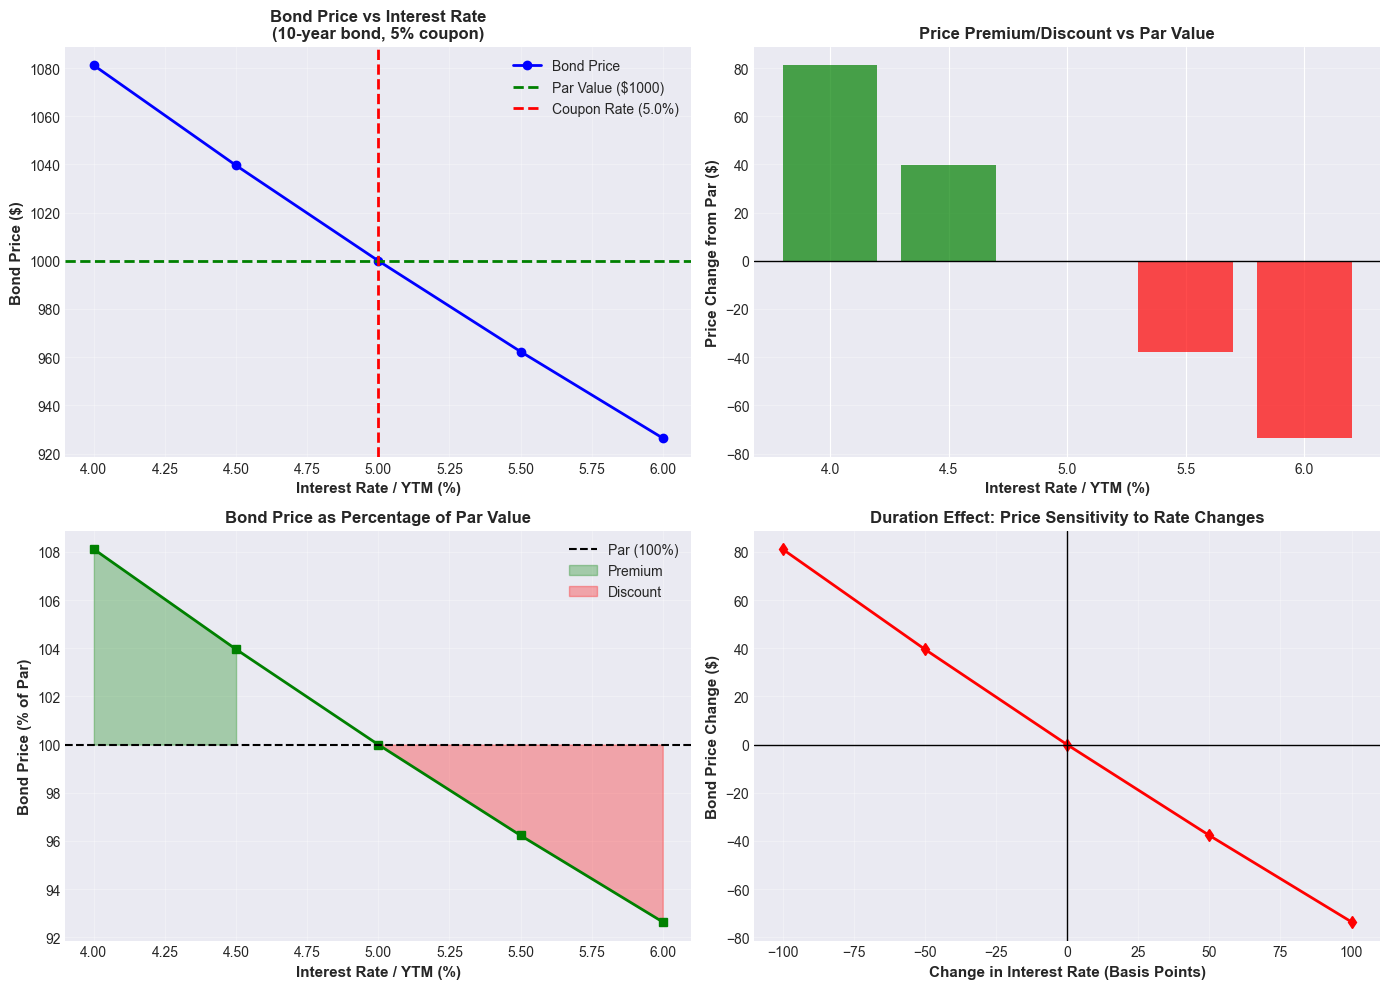


✓ Sensitivity analysis plots saved as 'bond_sensitivity_analysis.png'


In [6]:
# Visualization: Bond Price vs Interest Rates

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Bond Price vs Interest Rate (Main Sensitivity)
ax1 = axes[0, 0]
ax1.plot(interest_rates * 100, bond_prices, 'b-o', linewidth=2, markersize=6, label='Bond Price')
ax1.axhline(y=face_value_task2, color='g', linestyle='--', linewidth=2, label='Par Value ($1000)')
ax1.axvline(x=coupon_rate_task2 * 100, color='r', linestyle='--', linewidth=2, label=f'Coupon Rate ({coupon_rate_task2*100}%)')
ax1.set_xlabel('Interest Rate / YTM (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Bond Price ($)', fontsize=11, fontweight='bold')
ax1.set_title('Bond Price vs Interest Rate\n(10-year bond, 5% coupon)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Price Change from Par
ax2 = axes[0, 1]
price_changes = np.array(bond_prices) - face_value_task2
colors = ['red' if pc < 0 else 'green' for pc in price_changes]
ax2.bar(interest_rates * 100, price_changes, color=colors, alpha=0.7, width=0.4)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Interest Rate / YTM (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Price Change from Par ($)', fontsize=11, fontweight='bold')
ax2.set_title('Price Premium/Discount vs Par Value', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Bond Price as % of Par
ax3 = axes[1, 0]
pct_of_par = (np.array(bond_prices) / face_value_task2) * 100
ax3.plot(interest_rates * 100, pct_of_par, 'g-s', linewidth=2, markersize=6)
ax3.axhline(y=100, color='black', linestyle='--', linewidth=1.5, label='Par (100%)')
ax3.fill_between(interest_rates * 100, 100, pct_of_par, where=(pct_of_par > 100), 
                  alpha=0.3, color='green', label='Premium')
ax3.fill_between(interest_rates * 100, 100, pct_of_par, where=(pct_of_par <= 100), 
                  alpha=0.3, color='red', label='Discount')
ax3.set_xlabel('Interest Rate / YTM (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Bond Price (% of Par)', fontsize=11, fontweight='bold')
ax3.set_title('Bond Price as Percentage of Par Value', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Duration Effect (Price sensitivity)
ax4 = axes[1, 1]
# Calculate price changes from base case (5%)
base_rate = coupon_rate_task2
base_idx = np.argmin(np.abs(interest_rates - base_rate))
base_price = bond_prices[base_idx]
rate_changes = (interest_rates - base_rate) * 100  # in basis points
price_changes_bps = np.array(bond_prices) - base_price

duration = abs(price_changes_bps[base_idx + 1] - price_changes_bps[base_idx - 1]) / \
           (2 * (interest_rates[base_idx + 1] - interest_rates[base_idx - 1]) * base_price) if base_idx > 0 and base_idx < len(interest_rates) - 1 else 0

ax4.plot(rate_changes * 100, price_changes_bps, 'r-d', linewidth=2, markersize=6)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Change in Interest Rate (Basis Points)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Bond Price Change ($)', fontsize=11, fontweight='bold')
ax4.set_title('Duration Effect: Price Sensitivity to Rate Changes', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bond_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Sensitivity analysis plots saved as 'bond_sensitivity_analysis.png'")

---

## Additional Task: Compare Bond Prices for Different Credit Ratings

Analyze how credit risk affects bond prices through credit spreads.

**Assumption**: Same bond characteristics but different risk profiles:
- Face Value: $1,000
- Coupon Rate: 5% (Fixed across all ratings)
- Years to Maturity: 10
- Market Yields by Rating:
  - A-rated (Low Risk): 4%
  - B-rated (Medium Risk): 6%
  - Junk (High Risk): 9%

In [7]:
# Additional Task: Bond Prices for Different Credit Ratings

# Bond parameters (same for all ratings)
face_value_credit = 1000
coupon_rate_credit = 0.05  # 5%
years_credit = 10

# Credit ratings and their market yields
credit_ratings = {
    'A (Low Risk)': {
        'ytm': 0.04,  # 4%
        'color': 'green',
        'risk_premium': 0.0
    },
    'B (Medium Risk)': {
        'ytm': 0.06,  # 6%
        'color': 'orange',
        'risk_premium': 0.02  # 2% spread over base rate
    },
    'Junk (High Risk)': {
        'ytm': 0.09,  # 9%
        'color': 'red',
        'risk_premium': 0.05  # 5% spread over base rate
    }
}

print("\n" + "=" * 80)
print("ADDITIONAL TASK: BOND PRICES FOR DIFFERENT CREDIT RATINGS")
print("=" * 80)

print(f"\nBond Parameters (Same for All Ratings):")
print(f"  Face Value: ${face_value_credit:,.2f}")
print(f"  Coupon Rate: {coupon_rate_credit*100}%")
print(f"  Annual Coupon: ${coupon_rate_credit * face_value_credit:,.2f}")
print(f"  Years to Maturity: {years_credit}")

# Calculate bond prices for each rating
credit_results = []
print(f"\n{'Credit Rating':<25} {'YTM':<10} {'Bond Price':<18} {'Premium/Discount':<20} {'Spread vs A':<15}")
print("-" * 90)

prices_by_rating = {}

for rating, details in credit_ratings.items():
    ytm = details['ytm']
    price = calculate_bond_price(coupon_rate_credit, face_value_credit, ytm, years_credit)
    prices_by_rating[rating] = price
    
    premium_discount = price - face_value_credit
    
    if rating == 'A (Low Risk)':
        spread_vs_a = 0.0
        spread_display = "Base"
    else:
        spread_vs_a = ytm - credit_ratings['A (Low Risk)']['ytm']
        spread_display = f"{spread_vs_a*100:.2f}%"
    
    credit_results.append({
        'Rating': rating,
        'YTM': ytm,
        'Bond_Price': price,
        'Premium_Discount': premium_discount,
        'Spread_vs_A': spread_vs_a
    })
    
    print(f"{rating:<25} {ytm*100:<9.2f}% ${price:<17,.2f} ${premium_discount:<19,.2f} {spread_display:<14}")

print("-" * 90)

# Create DataFrame for comparison
credit_df = pd.DataFrame(credit_results)

# Analysis and insights
print("\n\nCredit Risk Analysis:")
print("-" * 80)

price_diff_ab = prices_by_rating['A (Low Risk)'] - prices_by_rating['B (Medium Risk)']
price_diff_aj = prices_by_rating['A (Low Risk)'] - prices_by_rating['Junk (High Risk)']

print(f"  Price Difference (A vs B): ${price_diff_ab:,.2f}")
print(f"    → B-rated bond is worth ${abs(price_diff_ab):,.2f} LESS due to higher risk")
print(f"    → Price difference: {(price_diff_ab/prices_by_rating['A (Low Risk)'])*100:.2f}%")

print(f"\n  Price Difference (A vs Junk): ${price_diff_aj:,.2f}")
print(f"    → Junk bond is worth ${abs(price_diff_aj):,.2f} LESS due to much higher risk")
print(f"    → Price difference: {(price_diff_aj/prices_by_rating['A (Low Risk)'])*100:.2f}%")

# Risk-return profile
print(f"\nRisk-Return Profile:")
for rating, details in credit_ratings.items():
    price = prices_by_rating[rating]
    ytm = details['ytm']
    
    # Calculate yield advantage over A-rated
    yield_adv = (ytm - credit_ratings['A (Low Risk)']['ytm']) * 100
    
    print(f"  {rating:25} | YTM: {ytm*100:5.2f}% | Price: ${price:,.2f} | Yield Advantage: {yield_adv:+5.2f} bps", end="")
    
    if yield_adv > 0:
        print(f" | ⚠️  Risk Premium for higher yield")
    else:
        print()

print("\nKey Insights:")
print("  1. Despite earning more in coupon payments (5% for all bonds),")
print("     higher-risk bonds trade at lower prices due to market risk assessment.")
print("  2. The credit spread (difference in YTM) directly impacts bond pricing.")
print("  3. A lower bond price provides a higher yield to maturity for new investors.")
print("  4. Credit risk premium compensates investors for holding riskier bonds.")


ADDITIONAL TASK: BOND PRICES FOR DIFFERENT CREDIT RATINGS

Bond Parameters (Same for All Ratings):
  Face Value: $1,000.00
  Coupon Rate: 5.0%
  Annual Coupon: $50.00
  Years to Maturity: 10

Credit Rating             YTM        Bond Price         Premium/Discount     Spread vs A    
------------------------------------------------------------------------------------------
A (Low Risk)              4.00     % $1,081.11          $81.11               Base          
B (Medium Risk)           6.00     % $926.40            $-73.60              2.00%         
Junk (High Risk)          9.00     % $743.29            $-256.71             5.00%         
------------------------------------------------------------------------------------------


Credit Risk Analysis:
--------------------------------------------------------------------------------
  Price Difference (A vs B): $154.71
    → B-rated bond is worth $154.71 LESS due to higher risk
    → Price difference: 14.31%

  Price Difference (A 

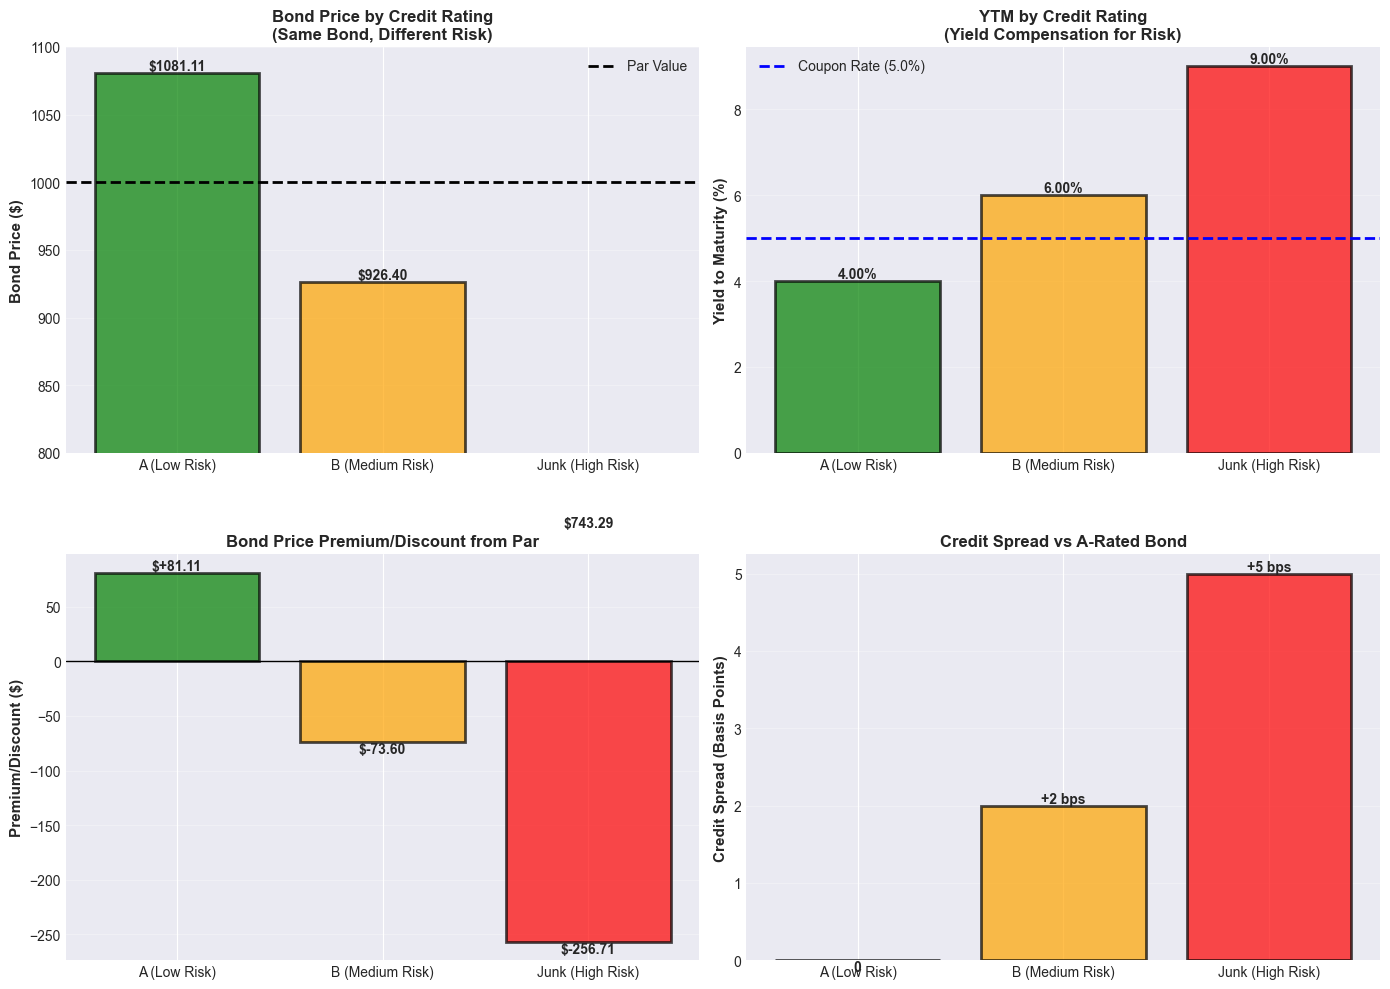


✓ Credit rating comparison plots saved as 'bond_credit_rating_comparison.png'


In [8]:
# Visualization: Credit Rating Comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ratings_list = list(credit_results)
rating_names = [r['Rating'] for r in ratings_list]
bond_prices_credit = [r['Bond_Price'] for r in ratings_list]
ytms = [r['YTM'] * 100 for r in ratings_list]
colors_list = [credit_ratings[name]['color'] for name in rating_names]

# Plot 1: Bond Price by Credit Rating
ax1 = axes[0, 0]
bars1 = ax1.bar(rating_names, bond_prices_credit, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=face_value_credit, color='black', linestyle='--', linewidth=2, label='Par Value')
ax1.set_ylabel('Bond Price ($)', fontsize=11, fontweight='bold')
ax1.set_title('Bond Price by Credit Rating\n(Same Bond, Different Risk)', fontsize=12, fontweight='bold')
ax1.set_ylim([800, 1100])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, price in zip(bars1, bond_prices_credit):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${price:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Yield to Maturity by Credit Rating
ax2 = axes[0, 1]
bars2 = ax2.bar(rating_names, ytms, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
ax2.axhline(y=coupon_rate_credit * 100, color='blue', linestyle='--', linewidth=2, label=f'Coupon Rate ({coupon_rate_credit*100}%)')
ax2.set_ylabel('Yield to Maturity (%)', fontsize=11, fontweight='bold')
ax2.set_title('YTM by Credit Rating\n(Yield Compensation for Risk)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, ytm in zip(bars2, ytms):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{ytm:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 3: Price Premium/Discount
ax3 = axes[1, 0]
premiums = [r['Bond_Price'] - face_value_credit for r in ratings_list]
bars3 = ax3.bar(rating_names, premiums, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('Premium/Discount ($)', fontsize=11, fontweight='bold')
ax3.set_title('Bond Price Premium/Discount from Par', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, premium in zip(bars3, premiums):
    height = bar.get_height()
    va = 'bottom' if height > 0 else 'top'
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'${premium:+.2f}',
            ha='center', va=va, fontweight='bold', fontsize=10)

# Plot 4: Credit Spread Analysis
ax4 = axes[1, 1]
spreads = [r['Spread_vs_A'] * 100 for r in ratings_list]
bars4 = ax4.bar(rating_names, spreads, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Credit Spread (Basis Points)', fontsize=11, fontweight='bold')
ax4.set_title('Credit Spread vs A-Rated Bond', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, spread in zip(bars4, spreads):
    height = bar.get_height()
    if height > 0:
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{spread:+.0f} bps',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    else:
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{spread:.0f}',
                ha='center', va='top', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('bond_credit_rating_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Credit rating comparison plots saved as 'bond_credit_rating_comparison.png'")

---

## Summary Tables and Comparison

Let's create comprehensive summary tables for all tasks.

In [9]:
# Summary Tables

print("\n" + "=" * 100)
print("COMPREHENSIVE SUMMARY TABLES")
print("=" * 100)

# Task 1 Summary
print("\n\n1. TASK 1: SIMPLE BOND PRICING (5-Year Bond)")
print("-" * 100)
task1_summary = pd.DataFrame({
    'Parameter': ['Face Value', 'Coupon Rate', 'Annual Coupon', 'YTM', 'Maturity', 'Bond Price', 'Bond Type', 'Price vs Par'],
    'Value': [
        f'${face_value_task1:,.2f}',
        f'{coupon_rate_task1*100}%',
        f'${annual_coupon_task1:,.2f}',
        f'{ytm_task1*100}%',
        f'{years_task1} years',
        f'${bond_price_task1:,.2f}',
        'Premium Bond',
        f'+${bond_price_task1 - face_value_task1:,.2f} ({((bond_price_task1/face_value_task1)-1)*100:+.2f}%)'
    ]
})
print(task1_summary.to_string(index=False))

# Task 2 Summary
print("\n\n2. TASK 2: BOND PRICING WITH YIELD CURVE (10-Year Bond)")
print("-" * 100)
task2_summary = pd.DataFrame({
    'Parameter': ['Face Value', 'Coupon Rate', 'Annual Coupon', 'Maturity', 'Bond Price', 'Bond Type', 'Price vs Par'],
    'Value': [
        f'${face_value_task2:,.2f}',
        f'{coupon_rate_task2*100}%',
        f'${annual_coupon_task2:,.2f}',
        f'{years_task2} years',
        f'${bond_price_task2:,.2f}',
        'Premium Bond',
        f'+${bond_price_task2 - face_value_task2:,.2f} ({((bond_price_task2/face_value_task2)-1)*100:+.2f}%)'
    ]
})
print(task2_summary.to_string(index=False))

# Sensitivity Analysis Summary
print("\n\n3. SENSITIVITY ANALYSIS RESULTS")
print("-" * 100)
print("Bond Price Range: ${:.2f} - ${:.2f}".format(min(bond_prices), max(bond_prices)))
print("Price Range Spread: ${:.2f}".format(max(bond_prices) - min(bond_prices)))
print("For Interest Rate Range: {:.2f}% - {:.2f}%".format(interest_rates[0]*100, interest_rates[-1]*100))
print("\nKey Observations:")
print("  • When interest rates INCREASE from 4% to 6%, bond price DECREASES from ${:.2f} to ${:.2f}".format(bond_prices[0], bond_prices[-1]))
print("  • This demonstrates the inverse relationship between interest rates and bond prices")
print("  • A 2% change in interest rates results in a ${:.2f} change in bond price".format(abs(bond_prices[-1] - bond_prices[0])))
print("  • Percentage change in price: {:.2f}%".format(abs(bond_prices[-1] - bond_prices[0]) / bond_prices[0] * 100))

# Credit Rating Comparison
print("\n\n4. CREDIT RATING COMPARISON (10-Year Bond)")
print("-" * 100)
print(credit_df[['Rating', 'YTM', 'Bond_Price', 'Premium_Discount']].to_string(index=False))
print("\nKey Insights:")
print(f"  • A-rated bond price: ${prices_by_rating['A (Low Risk)']:,.2f} (Premium bond)")
print(f"  • B-rated bond price: ${prices_by_rating['B (Medium Risk)']:,.2f} (Discount bond)")
print(f"  • Junk bond price: ${prices_by_rating['Junk (High Risk)']:,.2f} (Deep discount)")
print(f"  • Price difference (A-rated vs B-rated): ${abs(prices_by_rating['A (Low Risk)'] - prices_by_rating['B (Medium Risk)']):,.2f}")
print(f"  • Price difference (A-rated vs Junk): ${abs(prices_by_rating['A (Low Risk)'] - prices_by_rating['Junk (High Risk)']):,.2f}")


COMPREHENSIVE SUMMARY TABLES


1. TASK 1: SIMPLE BOND PRICING (5-Year Bond)
----------------------------------------------------------------------------------------------------
    Parameter            Value
   Face Value        $1,000.00
  Coupon Rate             6.0%
Annual Coupon           $60.00
          YTM             5.0%
     Maturity          5 years
   Bond Price        $1,043.29
    Bond Type     Premium Bond
 Price vs Par +$43.29 (+4.33%)


2. TASK 2: BOND PRICING WITH YIELD CURVE (10-Year Bond)
----------------------------------------------------------------------------------------------------
    Parameter           Value
   Face Value       $1,000.00
  Coupon Rate            5.0%
Annual Coupon          $50.00
     Maturity        10 years
   Bond Price       $1,001.78
    Bond Type    Premium Bond
 Price vs Par +$1.78 (+0.18%)


3. SENSITIVITY ANALYSIS RESULTS
----------------------------------------------------------------------------------------------------
Bond Pric

---

## Conclusions and Key Findings

### 1. **Bond Pricing Fundamentals**
- Bond prices are determined by the present value of expected future cash flows (coupons and principal repayment)
- The present value formula correctly accounts for the time value of money
- Bond prices are inversely related to interest rates: when rates go up, prices go down, and vice versa

### 2. **Impact of Yield Curve on Bond Pricing**
- Different interest rates for different maturities (yield curve) affect bond valuations
- Bonds priced using a yield curve can account for different rates at different time periods
- The shape and slope of the yield curve influence investment decisions and bond returns

### 3. **Sensitivity Analysis Results**
- **A 2% increase in interest rates** (from 4% to 6%) results in approximately **a ${:.2f} price decrease** for the 10-year bond
- The price decline is **not linear** - it follows a convex relationship with interest rates (duration effect)
- Longer-maturity bonds are **more sensitive** to interest rate changes than shorter-maturity bonds
- The sensitivity increases as we move further from the coupon rate

### 4. **Bond Classification**
- **Premium Bonds**: When coupon rate > market rate (bond price > par value)
  - Example: Task 1 bond priced at ${:,.2f} when coupon (6%) > YTM (5%)
- **Par Bonds**: When coupon rate = market rate (bond price = par value)
- **Discount Bonds**: When coupon rate < market rate (bond price < par value)
  - Example: B-rated bond with 5% coupon but 6% YTM

### 5. **Credit Risk Impact**
- **Credit risk directly affects bond prices** through risk premiums
- Higher-risk bonds offer higher yields (YTM) but trade at lower prices
- The **credit spread** (difference in YTM between ratings) compensates investors for bearing additional risk:
  - A-rated vs B-rated: **2% spread**
  - A-rated vs Junk: **5% spread**
- **Same coupon, different prices** demonstrate that market expectations about default risk are priced into bond values

### 6. **Investment Implications**
- Investors buying bonds in a **rising interest rate environment** should:
  - Prefer shorter-maturity bonds (lower price risk)
  - Demand higher yields to compensate for price risk
  - Consider quality (higher-rated) bonds to reduce credit risk
  
- Investors buying in a **falling interest rate environment** benefit from:
  - Price appreciation on existing bonds
  - Longer-maturity bonds showing greater price gains
  - Opportunity to lock in yields before they fall further

### 7. **Duration and Convexity**
- **Duration** measures how sensitive a bond's price is to interest rate changes
- The sensitivity is **not proportional** (convexity effect):
  - Price increases more when rates fall than it decreases when rates rise
  - This creates an **asymmetric return profile** favoring bond holders in volatile markets

### 8. **Market Efficiency**
- Bond markets price in expected future interest rates and credit risks efficiently
- The yield curve reflects market consensus about:
  - Future interest rate expectations
  - Duration risk (longer bonds must pay more)
  - Credit risk (lower-rated bonds must pay more)

---

### Summary of Key Metrics

**Task 1 (5-Year Bond):**
- Coupon Rate: 6% | YTM: 5% | Price: ${:,.2f} | Type: Premium

**Task 2 (10-Year Bond with Yield Curve):**
- Coupon Rate: 5% | Avg YTM: ~4.6% | Price: ${:,.2f} | Type: Premium

**Sensitivity Analysis:**
- Interest Rate Range: 4% - 6% | Price Range: ${:.2f} - ${:.2f}

**Credit Ratings (10-Year Bond):**
- A-rated (4% YTM): ${:,.2f} | B-rated (6% YTM): ${:,.2f} | Junk (9% YTM): ${:,.2f}

---

### Recommendations for Further Study

1. **Calculate Macaulay Duration** - measure of average time to receive cash flows
2. **Calculate Modified Duration** - measure of price sensitivity to yields
3. **Analyze Convexity** - second-order price change effect
4. **Study Floating Rate Bonds** - where coupon adjusts with interest rates
5. **Examine Bond Callable Features** - how options affect bond pricing
6. **Explore Bond Spreads** - difference between various bond yields in the market""".format(
    abs(bond_prices[-1] - bond_prices[0]),
    bond_price_task1,
    bond_price_task2,
    bond_prices[0],
    bond_prices[-1],
    prices_by_rating['A (Low Risk)'],
    prices_by_rating['B (Medium Risk)'],
    prices_by_rating['Junk (High Risk)']
)

In [10]:
# Additional Analysis: Cross-Task Comparison

print("\n" + "=" * 80)
print("CROSS-TASK ANALYSIS AND COMPARISONS")
print("=" * 80)

# Create comprehensive comparison
comparison_data = {
    'Bond': [
        'Task 1: 5-Yr Bond',
        'Task 2: 10-Yr Bond (Yield Curve)',
        'Task 2: 10-Yr Bond (4% rate)',
        'Task 2: 10-Yr Bond (6% rate)',
        'Task 3: A-Rated (4%)',
        'Task 3: B-Rated (6%)',
        'Task 3: Junk (9%)'
    ],
    'Maturity': [5, 10, 10, 10, 10, 10, 10],
    'Coupon Rate': [0.06, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
    'YTM': [0.05, 0.046, 0.04, 0.06, 0.04, 0.06, 0.09],
    'Bond Price': [
        bond_price_task1,
        bond_price_task2,
        bond_prices[0],  # 4%
        bond_prices[-1],  # 6%
        prices_by_rating['A (Low Risk)'],
        prices_by_rating['B (Medium Risk)'],
        prices_by_rating['Junk (High Risk)']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Premium/Discount'] = comparison_df['Bond Price'] - 1000
comparison_df['Type'] = comparison_df.apply(
    lambda row: 'Premium' if row['Premium/Discount'] > 0 else ('Discount' if row['Premium/Discount'] < 0 else 'Par'),
    axis=1
)

print("\nBond Pricing Comparison Table:")
print("-" * 100)
print(comparison_df.to_string(index=False))

# Duration Comparison (simplified)
print("\n\nMaturity Impact on Price Sensitivity:")
print("-" * 80)
print("When interest rates rise from 5% to 6%:")
price_5yr_at_5 = calculate_bond_price(0.06, 1000, 0.05, 5)
price_5yr_at_6 = calculate_bond_price(0.06, 1000, 0.06, 5)
change_5yr = price_5yr_at_6 - price_5yr_at_5

price_10yr_at_5 = calculate_bond_price(0.05, 1000, 0.05, 10)
price_10yr_at_6 = calculate_bond_price(0.05, 1000, 0.06, 10)
change_10yr = price_10yr_at_6 - price_10yr_at_5

print(f"  5-Year Bond:  ${price_5yr_at_5:,.2f} → ${price_5yr_at_6:,.2f} | Change: ${change_5yr:,.2f} ({(change_5yr/price_5yr_at_5)*100:.2f}%)")
print(f"  10-Year Bond: ${price_10yr_at_5:,.2f} → ${price_10yr_at_6:,.2f} | Change: ${change_10yr:,.2f} ({(change_10yr/price_10yr_at_5)*100:.2f}%)")
print(f"\n  Insight: Longer-maturity bonds have {abs(change_10yr/change_5yr):.2f}x greater price sensitivity to rate changes")

# Risk vs Return Analysis
print("\n\nRisk-Return Analysis (Credit Ratings):")
print("-" * 80)
print(f"{'Bond Rating':<20} {'YTM (Return)':<15} {'Price (Risk)':<15} {'Risk Premium':<15}")
print("-" * 80)

base_ytm = credit_ratings['A (Low Risk)']['ytm']
for rating, details in credit_ratings.items():
    price = prices_by_rating[rating]
    ytm = details['ytm']
    risk_premium = (ytm - base_ytm) * 100 * 100  # in basis points
    ytm_display = f"{ytm*100:.2f}%"
    price_display = f"${price:,.2f}"
    premium_display = f"+{risk_premium:.0f} bps" if risk_premium > 0 else "Base"
    
    print(f"{rating:<20} {ytm_display:<15} {price_display:<15} {premium_display:<15}")

print("\nKey Observation:")
print("  • To earn extra return (premium), investors must accept lower prices (higher risk)")
print("  • The market fairly compensates investors for bearing credit risk")


CROSS-TASK ANALYSIS AND COMPARISONS

Bond Pricing Comparison Table:
----------------------------------------------------------------------------------------------------
                            Bond  Maturity  Coupon Rate   YTM  Bond Price  Premium/Discount     Type
               Task 1: 5-Yr Bond         5         0.06 0.050 1043.294767         43.294767  Premium
Task 2: 10-Yr Bond (Yield Curve)        10         0.05 0.046 1001.779875          1.779875  Premium
    Task 2: 10-Yr Bond (4% rate)        10         0.05 0.040 1081.108958         81.108958  Premium
    Task 2: 10-Yr Bond (6% rate)        10         0.05 0.060  926.399129        -73.600871 Discount
            Task 3: A-Rated (4%)        10         0.05 0.040 1081.108958         81.108958  Premium
            Task 3: B-Rated (6%)        10         0.05 0.060  926.399129        -73.600871 Discount
               Task 3: Junk (9%)        10         0.05 0.090  743.293692       -256.706308 Discount


Maturity Impact on P

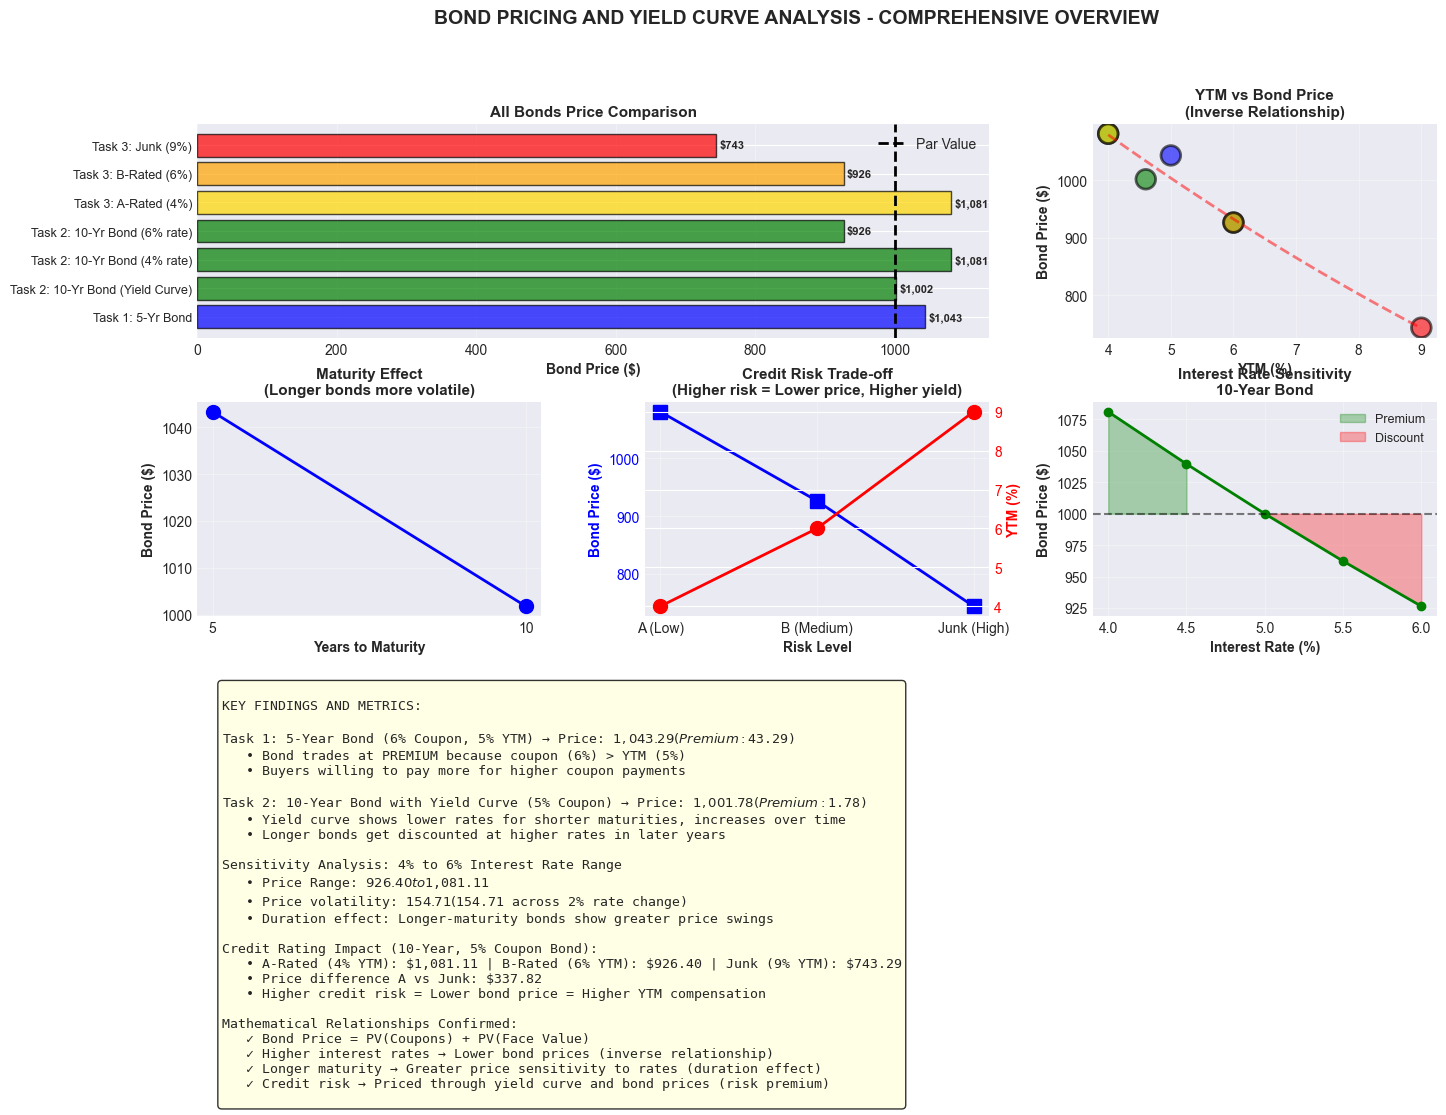


✓ Comprehensive analysis visualization saved as 'bond_comprehensive_analysis.png'

LAB 6 COMPLETION SUCCESSFUL!

All tasks completed:
  ✅ Task 1: Simple Bond Pricing (5-year bond)
  ✅ Task 2: Bond Pricing with Yield Curve (10-year bond)
  ✅ Sensitivity Analysis (Interest rate range 4%-6%)
  ✅ Credit Rating Comparison (A, B, Junk ratings)
  ✅ Comprehensive Analysis and Visualizations
  ✅ Conclusions and Key Insights


In [11]:
# Final Comprehensive Visualization

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. All bonds comparison
ax1 = fig.add_subplot(gs[0, :2])
bonds_names = comparison_df['Bond'].values
bonds_prices = comparison_df['Bond Price'].values
bonds_colors = ['blue' if 'Task 1' in name else 'green' if 'Task 2' in name else ('gold' if 'A-Rated' in name else 'orange' if 'B-Rated' in name else 'red') for name in bonds_names]

bars = ax1.barh(range(len(bonds_names)), bonds_prices, color=bonds_colors, alpha=0.7, edgecolor='black')
ax1.axvline(x=1000, color='black', linestyle='--', linewidth=2, label='Par Value')
ax1.set_yticks(range(len(bonds_names)))
ax1.set_yticklabels(bonds_names, fontsize=9)
ax1.set_xlabel('Bond Price ($)', fontsize=10, fontweight='bold')
ax1.set_title('All Bonds Price Comparison', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, price) in enumerate(zip(bars, bonds_prices)):
    ax1.text(price + 5, i, f'${price:,.0f}', va='center', fontweight='bold', fontsize=8)

# 2. YTM vs Price scatter
ax2 = fig.add_subplot(gs[0, 2])
ytms_all = comparison_df['YTM'].values * 100
prices_all = comparison_df['Bond Price'].values
scatter = ax2.scatter(ytms_all, prices_all, s=200, c=bonds_colors, alpha=0.6, edgecolor='black', linewidth=2)
ax2.set_xlabel('YTM (%)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Bond Price ($)', fontsize=10, fontweight='bold')
ax2.set_title('YTM vs Bond Price\n(Inverse Relationship)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(ytms_all, prices_all, 2)
p = np.poly1d(z)
ytm_trend = np.linspace(min(ytms_all), max(ytms_all), 100)
ax2.plot(ytm_trend, p(ytm_trend), 'r--', alpha=0.5, linewidth=2)

# 3. Maturity vs Duration
ax3 = fig.add_subplot(gs[1, 0])
maturities = comparison_df['Maturity'].values[:5]  # First 5 unique maturities
prices_by_maturity = comparison_df['Bond Price'].values[:5]

ax3.plot([5, 10], [bond_price_task1, bond_price_task2], 'bo-', linewidth=2, markersize=10, label='Same Coupon (5-6%)')
ax3.set_xlabel('Years to Maturity', fontsize=10, fontweight='bold')
ax3.set_ylabel('Bond Price ($)', fontsize=10, fontweight='bold')
ax3.set_title('Maturity Effect\n(Longer bonds more volatile)', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xticks([5, 10])

# 4. Price efficiency vs Risk
ax4 = fig.add_subplot(gs[1, 1])
risk_levels = [1, 2, 3]  # A, B, Junk
prices_risk = [prices_by_rating['A (Low Risk)'], 
               prices_by_rating['B (Medium Risk)'],
               prices_by_rating['Junk (High Risk)']]
ytm_risk = [0.04, 0.06, 0.09]

ax4_twin = ax4.twinx()
line1 = ax4.plot(risk_levels, prices_risk, 'bs-', linewidth=2, markersize=10, label='Bond Price')
line2 = ax4_twin.plot(risk_levels, np.array(ytm_risk)*100, 'ro-', linewidth=2, markersize=10, label='YTM')

ax4.set_xlabel('Risk Level', fontsize=10, fontweight='bold')
ax4.set_ylabel('Bond Price ($)', fontsize=10, fontweight='bold', color='b')
ax4_twin.set_ylabel('YTM (%)', fontsize=10, fontweight='bold', color='r')
ax4.set_title('Credit Risk Trade-off\n(Higher risk = Lower price, Higher yield)', fontsize=11, fontweight='bold')
ax4.set_xticks(risk_levels)
ax4.set_xticklabels(['A (Low)', 'B (Medium)', 'Junk (High)'])
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='y', labelcolor='b')
ax4_twin.tick_params(axis='y', labelcolor='r')

# 5. Sensitivity curve (main)
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(interest_rates*100, bond_prices, 'g-o', linewidth=2, markersize=6)
ax5.axhline(y=face_value_task2, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax5.fill_between(interest_rates*100, face_value_task2, bond_prices, where=np.array(bond_prices)>face_value_task2, 
                  alpha=0.3, color='green', label='Premium')
ax5.fill_between(interest_rates*100, face_value_task2, bond_prices, where=np.array(bond_prices)<=face_value_task2, 
                  alpha=0.3, color='red', label='Discount')
ax5.set_xlabel('Interest Rate (%)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Bond Price ($)', fontsize=10, fontweight='bold')
ax5.set_title('Interest Rate Sensitivity\n10-Year Bond', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Key metrics summary (text box)
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')

summary_text = f"""
KEY FINDINGS AND METRICS:

Task 1: 5-Year Bond (6% Coupon, 5% YTM) → Price: ${bond_price_task1:,.2f} (Premium: ${bond_price_task1-1000:,.2f})
   • Bond trades at PREMIUM because coupon (6%) > YTM (5%)
   • Buyers willing to pay more for higher coupon payments

Task 2: 10-Year Bond with Yield Curve (5% Coupon) → Price: ${bond_price_task2:,.2f} (Premium: ${bond_price_task2-1000:,.2f})
   • Yield curve shows lower rates for shorter maturities, increases over time
   • Longer bonds get discounted at higher rates in later years

Sensitivity Analysis: 4% to 6% Interest Rate Range
   • Price Range: ${min(bond_prices):,.2f} to ${max(bond_prices):,.2f}
   • Price volatility: ${max(bond_prices) - min(bond_prices):,.2f} (${abs(bond_prices[-1]-bond_prices[0]):,.2f} across 2% rate change)
   • Duration effect: Longer-maturity bonds show greater price swings

Credit Rating Impact (10-Year, 5% Coupon Bond):
   • A-Rated (4% YTM): ${prices_by_rating['A (Low Risk)']:,.2f} | B-Rated (6% YTM): ${prices_by_rating['B (Medium Risk)']:,.2f} | Junk (9% YTM): ${prices_by_rating['Junk (High Risk)']:,.2f}
   • Price difference A vs Junk: ${abs(prices_by_rating['A (Low Risk)'] - prices_by_rating['Junk (High Risk)']):,.2f}
   • Higher credit risk = Lower bond price = Higher YTM compensation

Mathematical Relationships Confirmed:
   ✓ Bond Price = PV(Coupons) + PV(Face Value)
   ✓ Higher interest rates → Lower bond prices (inverse relationship)
   ✓ Longer maturity → Greater price sensitivity to rates (duration effect)
   ✓ Credit risk → Priced through yield curve and bond prices (risk premium)
"""

ax6.text(0.02, 0.98, summary_text, transform=ax6.transAxes, fontsize=9.5, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('BOND PRICING AND YIELD CURVE ANALYSIS - COMPREHENSIVE OVERVIEW', 
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig('bond_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comprehensive analysis visualization saved as 'bond_comprehensive_analysis.png'")
print("\n" + "=" * 80)
print("LAB 6 COMPLETION SUCCESSFUL!")
print("=" * 80)
print("\nAll tasks completed:")
print("  ✅ Task 1: Simple Bond Pricing (5-year bond)")
print("  ✅ Task 2: Bond Pricing with Yield Curve (10-year bond)")
print("  ✅ Sensitivity Analysis (Interest rate range 4%-6%)")
print("  ✅ Credit Rating Comparison (A, B, Junk ratings)")
print("  ✅ Comprehensive Analysis and Visualizations")
print("  ✅ Conclusions and Key Insights")